In [11]:
import polars as pl

df_aapl = (
    pl.scan_parquet("./data_arthur/AAPL.OQ/*.parquet")
    .collect()
)

df_spy = (
    pl.scan_parquet("./data_arthur/SPY.P/*.parquet")
    .collect()
)
print(df_spy)

shape: (34_350_981, 5)
┌──────────────┬─────────────┬──────────────┬───────────────────────────┬──────────────────────────┐
│ xltime       ┆ trade-price ┆ trade-volume ┆ trade-stringflag          ┆ trade-rawflag            │
│ ---          ┆ ---         ┆ ---          ┆ ---                       ┆ ---                      │
│ f64          ┆ f64         ┆ i32          ┆ str                       ┆ str                      │
╞══════════════╪═════════════╪══════════════╪═══════════════════════════╪══════════════════════════╡
│ 39815.410054 ┆ 89.99       ┆ 100          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.4416   ┆ 90.01       ┆ 200          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.447097 ┆ 90.14       ┆ 100          ┆ marketclosed|volumeupd

In [12]:
df_aapl = (
    df_aapl
    .drop(["trade-stringflag", "trade-rawflag"])          # enlève les 2 dernières colonnes
    .drop_nulls(subset=["V1", "trade-price", "trade-volume"])  # enlève les lignes avec NaN/null
    .rename({
        "V1": "excel_time",
        "trade-price": "price",
        "trade-volume": "volume",
    })
)

df_spy = (
    df_spy
    .drop(["trade-stringflag", "trade-rawflag"])          # enlève les 2 dernières colonnes
    .drop_nulls(subset=["xltime", "trade-price", "trade-volume"])  # enlève les lignes avec NaN/null
    .rename({
        "xltime": "excel_time",
        "trade-price": "price",
        "trade-volume": "volume",
    })
)
    

In [13]:
import datetime as dt

origin = dt.datetime(1899, 12, 30)

df_aapl = df_aapl.with_columns(
    pl.col("excel_time")
    .map_elements(lambda x: origin + dt.timedelta(days=float(x)))
    .alias("datetime")
)

df_spy = df_spy.with_columns(
    pl.col("excel_time")
    .map_elements(lambda x: origin + dt.timedelta(days=float(x)))
    .alias("datetime")
)
# si tu veux trier :
df_aapl = df_aapl.sort("datetime")
df_spy = df_spy.sort("datetime")

print(df_spy.head())

shape: (5, 4)
┌──────────────┬───────┬────────┬─────────────────────────┐
│ excel_time   ┆ price ┆ volume ┆ datetime                │
│ ---          ┆ ---   ┆ ---    ┆ ---                     │
│ f64          ┆ f64   ┆ i32    ┆ datetime[μs]            │
╞══════════════╪═══════╪════════╪═════════════════════════╡
│ 39815.410054 ┆ 89.99 ┆ 100    ┆ 2009-01-02 09:50:28.685 │
│ 39815.4416   ┆ 90.01 ┆ 200    ┆ 2009-01-02 10:35:54.215 │
│ 39815.447097 ┆ 90.14 ┆ 100    ┆ 2009-01-02 10:43:49.222 │
│ 39815.450917 ┆ 90.05 ┆ 500    ┆ 2009-01-02 10:49:19.200 │
│ 39815.455288 ┆ 90.1  ┆ 300    ┆ 2009-01-02 10:55:36.912 │
└──────────────┴───────┴────────┴─────────────────────────┘


In [14]:
df_spy

excel_time,price,volume,datetime
f64,f64,i32,datetime[μs]
39815.410054,89.99,100,2009-01-02 09:50:28.685
39815.4416,90.01,200,2009-01-02 10:35:54.215
39815.447097,90.14,100,2009-01-02 10:43:49.222
39815.450917,90.05,500,2009-01-02 10:49:19.200
39815.455288,90.1,300,2009-01-02 10:55:36.912
…,…,…,…
40178.999887,111.01,100,2009-12-31 23:59:50.256
40178.999898,111.01,100,2009-12-31 23:59:51.222999
40178.999926,111.01,100,2009-12-31 23:59:53.597


In [15]:
df_aapl

excel_time,price,volume,datetime
f64,f64,f64,datetime[μs]
39815.526917,85.95,175.0,2009-01-02 12:38:45.595
39815.539092,86.15,200.0,2009-01-02 12:56:17.508
39815.541686,86.15,100.0,2009-01-02 13:00:01.699
39815.542877,86.0,174.0,2009-01-02 13:01:44.610
39815.543002,86.0,100.0,2009-01-02 13:01:55.361
…,…,…,…
40178.992194,210.7,160.0,2009-12-31 23:48:45.563
40178.992609,210.7,100.0,2009-12-31 23:49:21.431
40178.992642,210.7,100.0,2009-12-31 23:49:24.235


In [16]:
df_joined = df_aapl.join_asof(
    df_spy,
    on="datetime",
    strategy="nearest",     # "nearest" | "forward" | "backward"
    tolerance="500us"       # match only if within +/− 500 microseconds (optional)
).sort("datetime")


In [17]:
df_joined

excel_time,price,volume,datetime,excel_time_right,price_right,volume_right
f64,f64,f64,datetime[μs],f64,f64,i32
39815.526917,85.95,175.0,2009-01-02 12:38:45.595,null,null,null
39815.539092,86.15,200.0,2009-01-02 12:56:17.508,null,null,null
39815.541686,86.15,100.0,2009-01-02 13:00:01.699,null,null,null
39815.542877,86.0,174.0,2009-01-02 13:01:44.610,null,null,null
39815.543002,86.0,100.0,2009-01-02 13:01:55.361,null,null,null
…,…,…,…,…,…,…
40178.992194,210.7,160.0,2009-12-31 23:48:45.563,null,null,null
40178.992609,210.7,100.0,2009-12-31 23:49:21.431,null,null,null
40178.992642,210.7,100.0,2009-12-31 23:49:24.235,null,null,null


In [18]:
print("AAPL RANGE:", df_aapl.select([
    pl.min("datetime").alias("min"),
    pl.max("datetime").alias("max"),
    pl.count().alias("count")
]))

print("SPY RANGE:", df_spy.select([
    pl.min("datetime").alias("min"),
    pl.max("datetime").alias("max"),
    pl.count().alias("count")
]))


AAPL RANGE: shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬──────────┐
│ min                     ┆ max                     ┆ count    │
│ ---                     ┆ ---                     ┆ ---      │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32      │
╞═════════════════════════╪═════════════════════════╪══════════╡
│ 2009-01-02 12:38:45.595 ┆ 2009-12-31 23:56:13.203 ┆ 10876798 │
└─────────────────────────┴─────────────────────────┴──────────┘
SPY RANGE: shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬──────────┐
│ min                     ┆ max                     ┆ count    │
│ ---                     ┆ ---                     ┆ ---      │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32      │
╞═════════════════════════╪═════════════════════════╪══════════╡
│ 2009-01-02 09:50:28.685 ┆ 2009-12-31 23:59:55.284 ┆ 34350981 │
└─────────────────────────┴─────────────────────────┴──────────┘


/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_14716/2207966866.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")
/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_14716/2207966866.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


In [23]:
import polars as pl

df_aapl = df_aapl.unique()

# df_aapl
df_spy  = df_spy.unique()

# AAPL
df_aapl_deltas = (
    df_aapl.sort("datetime")
    .with_columns([
        (pl.col("datetime") - pl.col("datetime").shift(1))
            .alias("delta")
    ])
)

# SPY
df_spy_deltas = (
    df_spy.sort("datetime")
    .with_columns([
        (pl.col("datetime") - pl.col("datetime").shift(1))
            .alias("delta")
    ])
)


In [24]:
df_spy_deltas

excel_time,price,volume,datetime,delta
f64,f64,i32,datetime[μs],duration[μs]
39815.410054,89.99,100,2009-01-02 09:50:28.685,null
39815.4416,90.01,200,2009-01-02 10:35:54.215,45m 25s 530ms
39815.447097,90.14,100,2009-01-02 10:43:49.222,7m 55s 7ms
39815.450917,90.05,500,2009-01-02 10:49:19.200,5m 29s 978ms
39815.455288,90.1,300,2009-01-02 10:55:36.912,6m 17s 712ms
…,…,…,…,…
40178.999887,111.01,100,2009-12-31 23:59:50.256,945ms
40178.999898,111.01,100,2009-12-31 23:59:51.222999,966999µs
40178.999926,111.01,100,2009-12-31 23:59:53.597,2s 374001µs


In [25]:
print("AAPL delta statistics:")
print(df_aapl_deltas.select([
    pl.col("delta").mean().alias("mean"),
    pl.col("delta").std().alias("std"),
    pl.col("delta").min().alias("min"),
    pl.col("delta").max().alias("max"),
]))

print("SPY delta statistics:")
print(df_spy_deltas.select([
    pl.col("delta").mean().alias("mean"),
    pl.col("delta").std().alias("std"),
    pl.col("delta").min().alias("min"),
    pl.col("delta").max().alias("max"),
]))

AAPL delta statistics:
shape: (1, 4)
┌──────────────┬──────────────────┬──────────────┬─────────────────────┐
│ mean         ┆ std              ┆ min          ┆ max                 │
│ ---          ┆ ---              ┆ ---          ┆ ---                 │
│ duration[μs] ┆ duration[μs]     ┆ duration[μs] ┆ duration[μs]        │
╞══════════════╪══════════════════╪══════════════╪═════════════════════╡
│ 4s 82166µs   ┆ 10m 37s 260408µs ┆ 0µs          ┆ 3d 14h 6m 31s 519ms │
└──────────────┴──────────────────┴──────────────┴─────────────────────┘
SPY delta statistics:
shape: (1, 4)
┌──────────────┬─────────────────┬──────────────┬──────────────────────┐
│ mean         ┆ std             ┆ min          ┆ max                  │
│ ---          ┆ ---             ┆ ---          ┆ ---                  │
│ duration[μs] ┆ duration[μs]    ┆ duration[μs] ┆ duration[μs]         │
╞══════════════╪═════════════════╪══════════════╪══════════════════════╡
│ 1s 400248µs  ┆ 5m 46s 230888µs ┆ 0µs          ┆ 3

TypeError: float() argument must be a string or a real number, not 'datetime.timedelta'

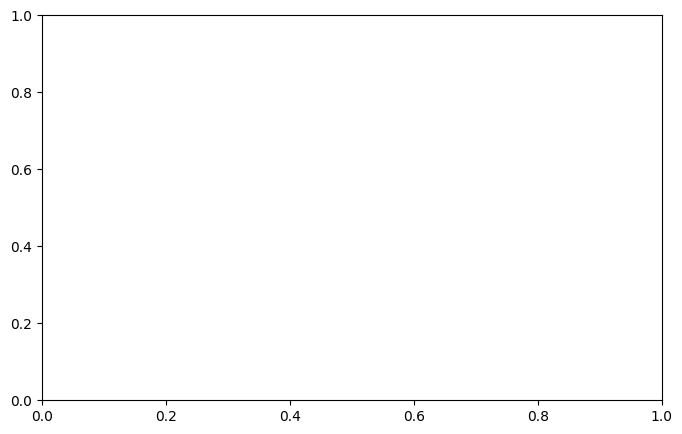

In [ ]:
quantiles = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]

print("AAPL quantiles:")
print(df_aapl_deltas.select(
    [pl.col("delta").quantile(q).alias(f"q{q}") for q in quantiles]
))

print("SPY quantiles:")
print(df_spy_deltas.select(
    [pl.col("delta").quantile(q).alias(f"q{q}") for q in quantiles]
))


In [28]:
(
    df_aapl
    .group_by("datetime")
    .agg(pl.count().alias("count"))
    .filter(pl.col("count") > 1)
    .sort("count", descending=True)
)


/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_14716/1253871136.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


datetime,count
datetime[μs],u32
2009-10-19 20:42:46.424,30
2009-11-23 14:59:57.985,24
2009-10-23 13:28:00.097999,24
2009-01-23 20:03:05.542,23
2009-02-10 16:24:41.557,23
…,…
2009-01-15 17:06:12.538,2
2009-03-05 21:00:04.982,2
2009-01-16 16:34:10.628,2


In [30]:
(
    df_spy
    .group_by("datetime")
    .agg(pl.count().alias("count"))
    .filter(pl.col("count") > 1)
    .sort("count", descending=True)
)


/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_14716/2076599546.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


datetime,count
datetime[μs],u32
2009-10-07 13:30:01.444001,65
2009-06-04 20:00:00.865,63
2009-03-02 14:30:04.526,61
2009-05-07 20:00:01.093,57
2009-02-05 14:30:01.913,57
…,…
2009-03-03 19:04:07.453,2
2009-01-08 14:54:35.972,2
2009-03-03 16:43:47.615,2


In [31]:
duplicates_with_differences_aapl = (
    df_aapl
    .group_by("datetime")
    .agg([
        pl.n_unique("price").alias("price_unique"),
        pl.n_unique("volume").alias("volume_unique"),
        pl.count().alias("count")
    ])
    .filter((pl.col("count") > 1) &
            ((pl.col("price_unique") > 1) | (pl.col("volume_unique") > 1)))
)

duplicates_with_differences_aapl


/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_14716/3603978932.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


datetime,price_unique,volume_unique,count
datetime[μs],u32,u32,u32
2009-12-22 18:05:37.982001,2,1,2
2009-11-12 15:32:39.276,1,2,2
2009-01-20 15:59:43.320,1,2,2
2009-03-31 18:23:00.081,1,2,2
2009-07-22 14:40:43.487,2,2,3
…,…,…,…
2009-01-02 16:50:09.309,3,2,4
2009-02-24 18:32:04.038,1,2,2
2009-01-14 15:58:50.230,1,2,2
